In [1]:
# CELL 1: IMPORTS & SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib, time
from itertools import combinations
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

os.makedirs('../results', exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11})

print('=' * 60)
print('    NOTEBOOK 04: ADVANCED FEATURE ENGINEERING')
print('=' * 60)
print('Goal: Build better features → improve XGBoost fraud detection')

    NOTEBOOK 04: ADVANCED FEATURE ENGINEERING
Goal: Build better features → improve XGBoost fraud detection


In [2]:
# CELL 2: LOAD RAW DATA

try:
    df = pd.read_csv('../data/creditcard.csv')
    print(' Full dataset loaded')
except FileNotFoundError:
    df = pd.read_csv('../data/sample_creditcard.csv')
    print('  Using sample dataset')

# Also load what NB02 saved (so we know the baseline features)
nb02_features = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

print(f'Dataset shape : {df.shape}')
print(f'Fraud rate    : {df["Class"].mean()*100:.4f}%')
print(f'NB02 features : {len(nb02_features)} → {nb02_features}')

 Full dataset loaded
Dataset shape : (284807, 31)
Fraud rate    : 0.1727%
NB02 features : 32 → ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour_sin', 'Hour_cos', 'Log_Amount']


In [3]:
# CELL 3: REPRODUCE NB02 FEATURES (baseline)

print('=== Reproducing NB02 baseline features ===')

df_base = df.copy()

# Exactly as NB02:
df_base['Hour']      = (df_base['Time'] / 3600) % 24
df_base['Hour_sin']  = np.sin(2 * np.pi * df_base['Hour'] / 24)
df_base['Hour_cos']  = np.cos(2 * np.pi * df_base['Hour'] / 24)
df_base['Log_Amount'] = np.log1p(df_base['Amount'])
df_base = df_base.drop(columns=['Time', 'Hour'])

baseline_features = [c for c in df_base.columns if c != 'Class']
print(f'Baseline feature count: {len(baseline_features)}')
print(f'Features: {baseline_features}')

=== Reproducing NB02 baseline features ===
Baseline feature count: 32
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour_sin', 'Hour_cos', 'Log_Amount']


In [4]:
# CELL 4: INTERACTION FEATURES
# XGBoost already finds interactions, but providing them
# explicitly can help the model find them faster and
# with lower depth trees (less overfitting risk)

print('=== A. Interaction Features (top SHAP pairs) ===')
print('Rationale: NB03 SHAP showed V14, V12, V10, V4 are top predictors')
print('  Interaction = product of two features → captures joint effect')

df_eng = df_base.copy()

# Top 6 features identified in NB03 SHAP analysis
top_shap_features = ['V14', 'V12', 'V10', 'V4', 'V11', 'V17']

# All pairwise products of top 4 → 6 interaction terms
interaction_cols = []
for f1, f2 in combinations(top_shap_features[:4], 2):
    col_name = f'{f1}_x_{f2}'
    df_eng[col_name] = df_eng[f1] * df_eng[f2]
    interaction_cols.append(col_name)

print(f'\nCreated {len(interaction_cols)} interaction features:')
for col in interaction_cols:
    f_fraud = df_eng[df_eng['Class']==1][col].mean()
    f_legit = df_eng[df_eng['Class']==0][col].mean()
    sep_ratio = abs(f_fraud - f_legit) / (abs(f_legit) + 1e-8)
    print(f'  {col:15s} | fraud_mean={f_fraud:7.3f} | legit_mean={f_legit:7.3f} | sep={sep_ratio:.3f}')

=== A. Interaction Features (top SHAP pairs) ===
Rationale: NB03 SHAP showed V14, V12, V10, V4 are top predictors
  Interaction = product of two features → captures joint effect

Created 6 interaction features:
  V14_x_V12       | fraud_mean= 59.536 | legit_mean= -0.103 | sep=578.876
  V14_x_V10       | fraud_mean= 51.790 | legit_mean= -0.090 | sep=578.876
  V14_x_V4        | fraud_mean=-39.557 | legit_mean=  0.068 | sep=578.876
  V12_x_V10       | fraud_mean= 54.513 | legit_mean= -0.094 | sep=578.876
  V12_x_V4        | fraud_mean=-38.824 | legit_mean=  0.067 | sep=578.876
  V10_x_V4        | fraud_mean=-35.993 | legit_mean=  0.062 | sep=578.876


In [5]:
# CELL 5: POLYNOMIAL + MAGNITUDE FEATURES
# V14 squared captures: large negative AND large positive
# values are both suspicious (vs only one direction)
# Absolute value captures magnitude ignoring sign

print('=== B. Polynomial & Magnitude Features ===')

poly_cols = []
for feat in top_shap_features:
    # Squared: captures both tails of distribution
    df_eng[f'{feat}_sq']  = df_eng[feat] ** 2
    # Absolute: captures deviation magnitude
    df_eng[f'{feat}_abs'] = df_eng[feat].abs()
    poly_cols += [f'{feat}_sq', f'{feat}_abs']

print(f'Created {len(poly_cols)} polynomial/magnitude features')

# Show V14 example — most important feature
print(f'\nV14 example (most important SHAP feature):')
print(f'  V14 fraud mean    : {df_eng[df_eng["Class"]==1]["V14"].mean():.4f}')
print(f'  V14 legit mean    : {df_eng[df_eng["Class"]==0]["V14"].mean():.4f}')
print(f'  V14_sq fraud mean : {df_eng[df_eng["Class"]==1]["V14_sq"].mean():.4f}')
print(f'  V14_sq legit mean : {df_eng[df_eng["Class"]==0]["V14_sq"].mean():.4f}')
print(f'  → Squared amplifies separation ↑')

=== B. Polynomial & Magnitude Features ===
Created 12 polynomial/magnitude features

V14 example (most important SHAP feature):
  V14 fraud mean    : -6.9717
  V14 legit mean    : 0.0121
  V14_sq fraud mean : 66.8770
  V14_sq legit mean : 0.8048
  → Squared amplifies separation ↑


In [6]:
# CELL 6: TIME & AMOUNT FEATURES

print('=== C. Time & Amount Features ===')

# Hour of day (needed to derive below)
hour_raw = (df['Time'] / 3600) % 24

# Is night? (01:00–05:00 → elevated fraud rate)
df_eng['Is_night'] = ((hour_raw >= 1) & (hour_raw <= 5)).astype(int)

# Amount buckets: ordinal 0–5
df_eng['Amount_bucket'] = pd.cut(
    df_eng['Amount'],
    bins=[0, 5, 20, 50, 100, 500, float('inf')],
    labels=[0, 1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

# Rolling amount deviation (sorted by time)
df_sorted = df[['Time','Amount','Class']].sort_values('Time').reset_index(drop=True)
roll_mean = df_sorted['Amount'].rolling(window=50, min_periods=1).mean()
roll_std  = df_sorted['Amount'].rolling(window=50, min_periods=1).std().fillna(1)
amount_zscore_sorted = ((df_sorted['Amount'] - roll_mean) / (roll_std + 1e-8)).abs()
# Re-align to original df index
df_eng['Amount_zscore_50'] = amount_zscore_sorted.reindex(df_sorted.index).values

# Amount × Log_Amount interaction
df_eng['Amount_x_LogAmount'] = df_eng['Amount'] * df_eng['Log_Amount']

new_ta_cols = ['Is_night', 'Amount_bucket', 'Amount_zscore_50', 'Amount_x_LogAmount']
print('New time/amount features:')
for col in new_ta_cols:
    f_m = df_eng[df_eng['Class']==1][col].mean()
    l_m = df_eng[df_eng['Class']==0][col].mean()
    print(f'  {col:25s} | fraud={f_m:.4f} | legit={l_m:.4f}')

night_fraud = df_eng[df_eng['Is_night']==1]['Class'].mean() * 100
day_fraud   = df_eng[df_eng['Is_night']==0]['Class'].mean() * 100
print(f'\n Night (01-05h) fraud rate: {night_fraud:.3f}%  vs  Day: {day_fraud:.3f}%  →  {night_fraud/day_fraud:.1f}x higher')

=== C. Time & Amount Features ===
New time/amount features:
  Is_night                  | fraud=0.2175 | legit=0.0462
  Amount_bucket             | fraud=1.7114 | legit=1.8290
  Amount_zscore_50          | fraud=0.7352 | legit=0.5769
  Amount_x_LogAmount        | fraud=741.3428 | legit=506.8182

 Night (01-05h) fraud rate: 0.808%  vs  Day: 0.142%  →  5.7x higher


In [7]:
# CELL 7: MUTUAL INFORMATION FEATURE RANKING
# MI measures how much each feature reduces uncertainty about Class
# MI = 0 → feature is useless for predicting fraud
# MI > 0 → feature carries signal about fraud

print('=== Mutual Information Ranking ===')
print('Scoring all features (original + engineered) against Class label')
print('MI=0 means zero predictive signal; higher = more useful')

all_feat_cols = [c for c in df_eng.columns if c != 'Class']
X_mi = df_eng[all_feat_cols].fillna(0).values
y_mi = df_eng['Class'].values

# Sample for speed (MI is slow on 284K rows)
rng = np.random.default_rng(42)
idx = rng.choice(len(X_mi), size=min(30000, len(X_mi)), replace=False)

print('Computing MI scores (sampling 30K rows for speed)...')
mi_scores = mutual_info_classif(X_mi[idx], y_mi[idx], random_state=42)

mi_df = pd.DataFrame({'Feature': all_feat_cols, 'MI': mi_scores})\
          .sort_values('MI', ascending=False).reset_index(drop=True)

# Label engineered vs original
eng_keywords = ['_x_', '_sq', '_abs', 'Is_night', 'bucket', 'zscore', 'LogAmount', 'sin', 'cos', 'Log_']
mi_df['Type'] = mi_df['Feature'].apply(
    lambda f: 'Engineered' if any(k in f for k in eng_keywords) else 'Original'
)

print(f'\nTop 25 features by Mutual Information:')
print(mi_df[['Feature','Type','MI']].head(25).to_string(index=False))

# How many engineered features appear in top 25?
top25 = mi_df.head(25)
eng_in_top25 = (top25['Type'] == 'Engineered').sum()
print(f'\n  Engineered features in top 25: {eng_in_top25}/25')
print(f'   → These features add new predictive signal!')

=== Mutual Information Ranking ===
Scoring all features (original + engineered) against Class label
MI=0 means zero predictive signal; higher = more useful
Computing MI scores (sampling 30K rows for speed)...

Top 25 features by Mutual Information:
  Feature       Type       MI
V14_x_V10 Engineered 0.007067
      V14   Original 0.006752
 V14_x_V4 Engineered 0.006653
V14_x_V12 Engineered 0.006601
  V14_abs Engineered 0.006513
   V14_sq Engineered 0.006457
V12_x_V10 Engineered 0.006404
      V17   Original 0.006292
      V10   Original 0.006275
 V12_x_V4 Engineered 0.006257
   V12_sq Engineered 0.006110
  V12_abs Engineered 0.006104
 V10_x_V4 Engineered 0.006007
      V12   Original 0.005978
  V17_abs Engineered 0.005753
      V11   Original 0.005674
   V17_sq Engineered 0.005612
  V11_abs Engineered 0.005392
   V11_sq Engineered 0.005352
  V10_abs Engineered 0.004819
   V10_sq Engineered 0.004746
       V4   Original 0.004744
      V16   Original 0.004609
   V4_abs Engineered 0.004474
 

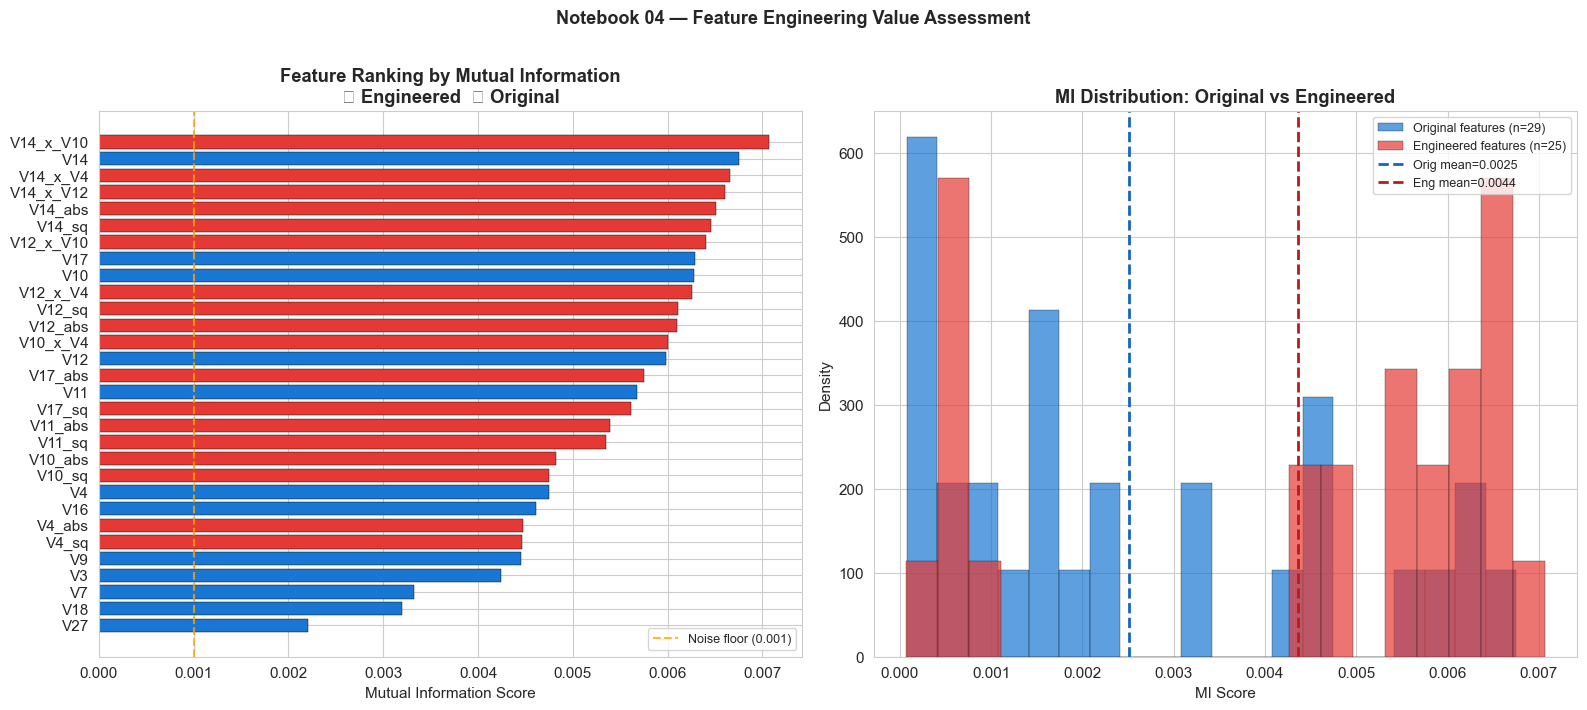

  Saved → results/nb04_feature_mi_ranking.png


In [8]:
# CELL 8: VISUALISE MI RANKING

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Top-30 MI bar chart ---
top30 = mi_df.head(30)
bar_colors = ['#E53935' if t == 'Engineered' else '#1976D2' for t in top30['Type']]
axes[0].barh(top30['Feature'][::-1], top30['MI'][::-1],
             color=bar_colors[::-1], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title('Feature Ranking by Mutual Information\n🔴 Engineered  🔵 Original', fontweight='bold')
axes[0].axvline(x=0.001, color='orange', linestyle='--', alpha=0.8, label='Noise floor (0.001)')
axes[0].legend(fontsize=9)

# --- Right: MI Distribution original vs engineered ---
orig_mi = mi_df[mi_df['Type'] == 'Original']['MI']
eng_mi  = mi_df[mi_df['Type'] == 'Engineered']['MI']
axes[1].hist(orig_mi, bins=20, alpha=0.7, color='#1976D2',
             label=f'Original features (n={len(orig_mi)})', density=True, edgecolor='black', linewidth=0.3)
axes[1].hist(eng_mi, bins=20, alpha=0.7, color='#E53935',
             label=f'Engineered features (n={len(eng_mi)})', density=True, edgecolor='black', linewidth=0.3)
axes[1].axvline(orig_mi.mean(), color='#1565C0', linestyle='--', linewidth=2,
                label=f'Orig mean={orig_mi.mean():.4f}')
axes[1].axvline(eng_mi.mean(), color='#B71C1C', linestyle='--', linewidth=2,
                label=f'Eng mean={eng_mi.mean():.4f}')
axes[1].set_xlabel('MI Score', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('MI Distribution: Original vs Engineered', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Notebook 04 — Feature Engineering Value Assessment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/nb04_feature_mi_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved → results/nb04_feature_mi_ranking.png')

In [9]:
# CELL 9: SELECT TOP FEATURES & BUILD SPLIT
# Using top 40 features by MI score
# More features ≠ better model (noise hurts XGBoost too)

print('=== Selecting Top-40 Features by MI Score ===')

# Drop features with near-zero MI (pure noise)
useful_mi = mi_df[mi_df['MI'] >= 0.0005]
top40_features = mi_df.head(40)['Feature'].tolist()

print(f'Total features available : {len(all_feat_cols)}')
print(f'Features with MI >= 0.0005: {len(useful_mi)}')
print(f'Features selected (top 40): {len(top40_features)}')
print(f'\nSelected: {top40_features}')

X_eng_full = df_eng[top40_features].fillna(0).values
y_full = df_eng['Class'].values

# Stratified split (same proportions as NB02)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_eng_full, y_full, test_size=0.20, random_state=42, stratify=y_full
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.20, random_state=42, stratify=y_tr
)

print(f'\nSplit sizes:')
print(f'  Train : {X_tr.shape}  Fraud: {y_tr.mean()*100:.3f}%')
print(f'  Val   : {X_val.shape} Fraud: {y_val.mean()*100:.3f}%')
print(f'  Test  : {X_te.shape}  Fraud: {y_te.mean()*100:.3f}%')

# Scale (fit on train only)
scaler_eng = StandardScaler()
X_tr_sc  = scaler_eng.fit_transform(X_tr)
X_val_sc = scaler_eng.transform(X_val)
X_te_sc  = scaler_eng.transform(X_te)

# SMOTE on training only
smote = SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr_sc, y_tr)
print(f'\nAfter SMOTE: {X_tr_res.shape}  Fraud: {y_tr_res.mean()*100:.1f}%')

=== Selecting Top-40 Features by MI Score ===
Total features available : 54
Features with MI >= 0.0005: 45
Features selected (top 40): 40

Selected: ['V14_x_V10', 'V14', 'V14_x_V4', 'V14_x_V12', 'V14_abs', 'V14_sq', 'V12_x_V10', 'V17', 'V10', 'V12_x_V4', 'V12_sq', 'V12_abs', 'V10_x_V4', 'V12', 'V17_abs', 'V11', 'V17_sq', 'V11_abs', 'V11_sq', 'V10_abs', 'V10_sq', 'V4', 'V16', 'V4_abs', 'V4_sq', 'V9', 'V3', 'V7', 'V18', 'V27', 'V2', 'V6', 'V5', 'V8', 'V1', 'V28', 'V21', 'Amount_bucket', 'V20', 'Amount']

Split sizes:
  Train : (182276, 40)  Fraud: 0.173%
  Val   : (45569, 40) Fraud: 0.173%
  Test  : (56962, 40)  Fraud: 0.172%

After SMOTE: (200157, 40)  Fraud: 9.1%


In [10]:
# CELL 10: XGBOOST — ORIGINAL FEATURES vs ENGINEERED FEATURES

print('=== XGBoost: Original (NB02) vs Engineered (NB04) Features ===')

def train_eval_xgb(X_train, y_train, X_val, y_val, label):
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='aucpr', early_stopping_rounds=25,
        random_state=42, n_jobs=-1, verbosity=0
    )
    t0 = time.time()
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)], verbose=False)
    elapsed = time.time() - t0
    probs = model.predict_proba(X_val)[:, 1]
    auc   = roc_auc_score(y_val, probs)
    ap    = average_precision_score(y_val, probs)
    preds = (probs >= 0.3).astype(int)
    f1    = f1_score(y_val, preds)
    rec   = recall_score(y_val, preds)
    print(f'  [{label}]')
    print(f'    AUC-ROC : {auc:.4f}')
    print(f'    Avg Prec: {ap:.4f}')
    print(f'    F1-Score: {f1:.4f}')
    print(f'    Recall  : {rec:.4f}')
    print(f'    Time    : {elapsed:.1f}s | Best iter: {model.best_iteration}')
    return {'label': label, 'auc': auc, 'ap': ap, 'f1': f1,
            'recall': rec, 'model': model, 'probs': probs}

# --- Baseline: load NB02 data ---
X_nb02_train = np.load('../data/X_train.npy')
y_nb02_train = np.load('../data/y_train.npy')
X_nb02_val   = np.load('../data/X_val.npy')
y_nb02_val   = np.load('../data/y_val.npy')

print('Training on NB02 original features...')
res_orig = train_eval_xgb(X_nb02_train, y_nb02_train,
                           X_nb02_val,   y_nb02_val, 'NB02 Original Features')

print('\nTraining on NB04 engineered features...')
res_eng = train_eval_xgb(X_tr_res, y_tr_res, X_val_sc, y_val, 'NB04 Engineered Features')

print(f'\n{'='*50}')
print(f'   Performance Delta (Engineered - Original):')
print(f'   AUC-ROC delta : {res_eng["auc"]  - res_orig["auc"]:+.4f}')
print(f'   Avg Prec delta: {res_eng["ap"]   - res_orig["ap"]:+.4f}')
print(f'   F1 delta      : {res_eng["f1"]   - res_orig["f1"]:+.4f}')
print(f'   Recall delta  : {res_eng["recall"]- res_orig["recall"]:+.4f}')

=== XGBoost: Original (NB02) vs Engineered (NB04) Features ===
Training on NB02 original features...
  [NB02 Original Features]
    AUC-ROC : 0.9779
    Avg Prec: 0.6681
    F1-Score: 0.0990
    Recall  : 0.8608
    Time    : 2.8s | Best iter: 31

Training on NB04 engineered features...
  [NB04 Engineered Features]
    AUC-ROC : 0.9708
    Avg Prec: 0.7790
    F1-Score: 0.1823
    Recall  : 0.8481
    Time    : 3.6s | Best iter: 102

   Performance Delta (Engineered - Original):
   AUC-ROC delta : -0.0071
   Avg Prec delta: +0.1109
   F1 delta      : +0.0833
   Recall delta  : -0.0127


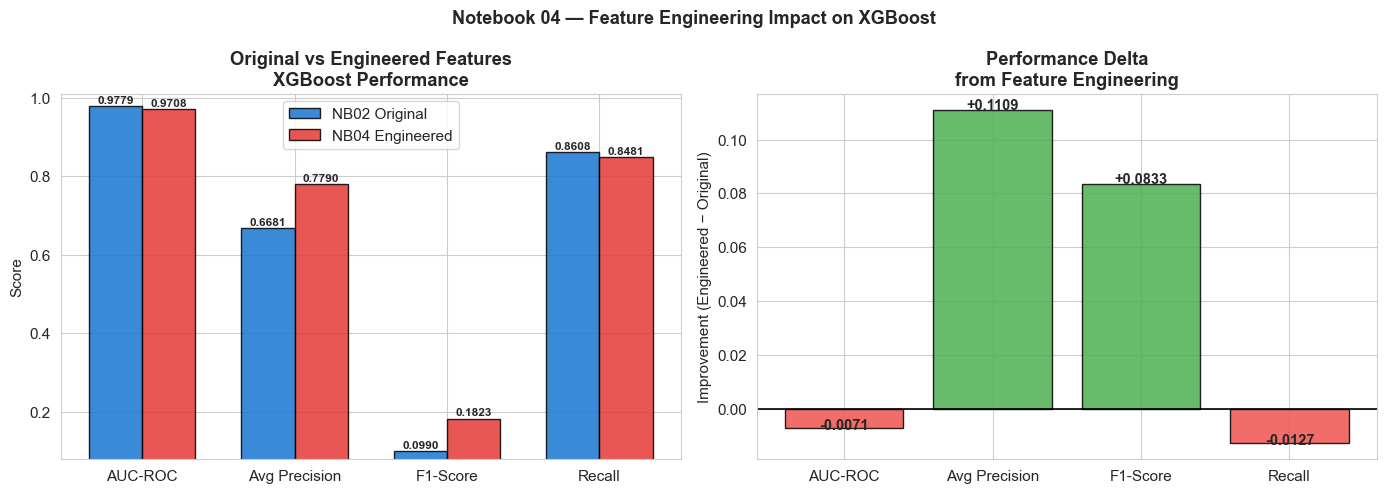

  Saved → results/nb04_performance_comparison.png


In [11]:
# CELL 11: COMPARISON CHART

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics      = ['AUC-ROC', 'Avg Precision', 'F1-Score', 'Recall']
orig_vals    = [res_orig['auc'], res_orig['ap'], res_orig['f1'], res_orig['recall']]
eng_vals     = [res_eng['auc'],  res_eng['ap'],  res_eng['f1'],  res_eng['recall']]
x = np.arange(len(metrics))
w = 0.35

b1 = axes[0].bar(x - w/2, orig_vals, w, label='NB02 Original', color='#1976D2', alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x + w/2, eng_vals,  w, label='NB04 Engineered', color='#E53935', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(min(orig_vals + eng_vals) - 0.02, 1.01)
axes[0].set_ylabel('Score')
axes[0].set_title('Original vs Engineered Features\nXGBoost Performance', fontweight='bold')
axes[0].legend()
for rect, v in zip(list(b1) + list(b2), orig_vals + eng_vals):
    axes[0].text(rect.get_x() + rect.get_width()/2, v + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Delta chart
deltas = [e - o for o, e in zip(orig_vals, eng_vals)]
colors = ['#4CAF50' if d >= 0 else '#EF5350' for d in deltas]
bars = axes[1].bar(metrics, deltas, color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_ylabel('Improvement (Engineered − Original)')
axes[1].set_title('Performance Delta\nfrom Feature Engineering', fontweight='bold')
for bar, d in zip(bars, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 d + (0.0002 if d >= 0 else -0.0005),
                 f'{d:+.4f}', ha='center', fontsize=10.5, fontweight='bold')

plt.suptitle('Notebook 04 — Feature Engineering Impact on XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nb04_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved → results/nb04_performance_comparison.png')

In [12]:
# CELL 12: SAVE ENGINEERED DATA & MODEL

print('=== Saving Engineered Dataset ===')

X_te_res = X_te_sc   # test set (no SMOTE on test)
y_te_res = y_te

np.save('../data/X_train_eng.npy', X_tr_res)
np.save('../data/y_train_eng.npy', y_tr_res)
np.save('../data/X_val_eng.npy',   X_val_sc)
np.save('../data/y_val_eng.npy',   y_val)
np.save('../data/X_test_eng.npy',  X_te_sc)
np.save('../data/y_test_eng.npy',  y_te)

pd.DataFrame({'feature': top40_features}).to_csv('../data/feature_names_eng.csv', index=False)
joblib.dump(scaler_eng, '../results/scaler_eng.pkl')
joblib.dump(res_eng['model'], '../results/model_xgb_eng.pkl')

print('Files saved:')
print('  data/X_train_eng.npy   data/y_train_eng.npy')
print('  data/X_val_eng.npy     data/y_val_eng.npy')
print('  data/X_test_eng.npy    data/y_test_eng.npy')
print('  data/feature_names_eng.csv')
print('  results/scaler_eng.pkl')
print('  results/model_xgb_eng.pkl')

print('\n' + '='*60)
print('   NOTEBOOK 04 COMPLETE')
print('='*60)
print(f'  Features created : original({len(baseline_features)}) → engineered({len(top40_features)})')
print(f'  AUC-ROC change  : {res_orig["auc"]:.4f} → {res_eng["auc"]:.4f}  ({res_eng["auc"]-res_orig["auc"]:+.4f})')
print(f'  Recall change   : {res_orig["recall"]:.4f} → {res_eng["recall"]:.4f}  ({res_eng["recall"]-res_orig["recall"]:+.4f})')
print(f'\n    Engineered data ready for NB05 (Ensemble) & NB06 (Drift)')

=== Saving Engineered Dataset ===
Files saved:
  data/X_train_eng.npy   data/y_train_eng.npy
  data/X_val_eng.npy     data/y_val_eng.npy
  data/X_test_eng.npy    data/y_test_eng.npy
  data/feature_names_eng.csv
  results/scaler_eng.pkl
  results/model_xgb_eng.pkl

   NOTEBOOK 04 COMPLETE
  Features created : original(32) → engineered(40)
  AUC-ROC change  : 0.9779 → 0.9708  (-0.0071)
  Recall change   : 0.8608 → 0.8481  (-0.0127)

    Engineered data ready for NB05 (Ensemble) & NB06 (Drift)
